In [157]:
import pandas as pd
df = pd.read_csv("grades_crpt.csv")

## Data Exploration
#### **Look at basic stats, column names, and what the data looks like**

9 Columns & Their Names:
- A1-7
- Final_Exam
- user_id

The data looks like a database entry of each student's grade from their assingments and then the score of their final exam.

- The only column that isn't a floating number is the user_id


#### **Identify anything that stands out right away**

- Scores can go above 100
    - For example, user_id = U008 in A1 has a score of 168.9

- Scores can dip into the negatives (beyond 0)
    - For example, user_id = U068 has a score of -21.6 in A4
    - user_id = U013 has a score of -69.3 in A3

- There are many missing score entries across the assignments for many of the students



#### df.head() & info
Tells me the basic information of the data ex. column names and their entry.
- The head gives me the full information for the first 4 entries of the data


In [158]:
df.head()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,NaN,NaN,30.0,75.0,90.0,65.0,50.6,68.8,U001
1,100.0,NaN,NaN,92.5,100.0,100.0,84.4,50.3,U002
2,75.0,69.6,NaN,86.2,100.0,NaN,NaN,67.8,U003
3,25.0,78.6,40.0,0.0,50.0,30.7,0.0,0.0,U004
4,0.0,NaN,0.0,0.0,NaN,NaN,NaN,0.0,U005


In [159]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   A1          57 non-null     float64
 1   A2          61 non-null     float64
 2   A3          62 non-null     float64
 3   A4          77 non-null     float64
 4   A5          61 non-null     float64
 5   A6          67 non-null     float64
 6   A7          76 non-null     float64
 7   Final_Exam  86 non-null     float64
 8   user_id     86 non-null     str    
dtypes: float64(8), str(1)
memory usage: 6.2 KB


#### df.describe()

df.describe() helps me see the mean, median, min, and standard deviations of each data column
- it also gives me the lower pecentile (25%) and the upper percentile (75%)

- The count tells me how many non-null or missing data entries there are in the column

In [160]:
df.describe()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam
count,57.000000,61.000000,62.000000,77.000000,61.000000,67.000000,76.000000,86.000000
mean,83.671930,81.096721,68.174194,82.332468,89.645902,74.437313,78.130263,55.509302
std,34.286481,28.556721,42.343621,39.101984,25.510505,31.176535,26.412058,18.176777
min,-4.500000,-30.600000,-70.100000,-21.600000,7.700000,-17.000000,0.000000,0.000000
25%,75.800000,64.300000,50.000000,72.000000,87.000000,60.000000,70.300000,45.850000
50%,87.500000,91.100000,80.000000,87.500000,95.000000,80.000000,80.000000,56.050000
75%,95.800000,100.000000,93.250000,95.000000,100.000000,92.500000,87.500000,67.725000
max,174.600000,148.900000,152.200000,188.200000,173.900000,183.600000,150.600000,97.500000


## Check the correlations

#### **Use a correlation matrix to find relationships between assignments and the final exam**



In [161]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'Final_Exam']
corr_matrix = df[numeric_cols].corr()

print(corr_matrix.round(2))

              A1    A2    A3    A4    A5    A6    A7  Final_Exam
A1          1.00 -0.14  0.36  0.30  0.24  0.23 -0.02        0.21
A2         -0.14  1.00  0.21 -0.03  0.01  0.36  0.03        0.28
A3          0.36  0.21  1.00  0.19  0.19 -0.03  0.15        0.28
A4          0.30 -0.03  0.19  1.00  0.04  0.15  0.22        0.40
A5          0.24  0.01  0.19  0.04  1.00  0.24  0.03        0.02
A6          0.23  0.36 -0.03  0.15  0.24  1.00  0.15        0.25
A7         -0.02  0.03  0.15  0.22  0.03  0.15  1.00        0.38
Final_Exam  0.21  0.28  0.28  0.40  0.02  0.25  0.38        1.00


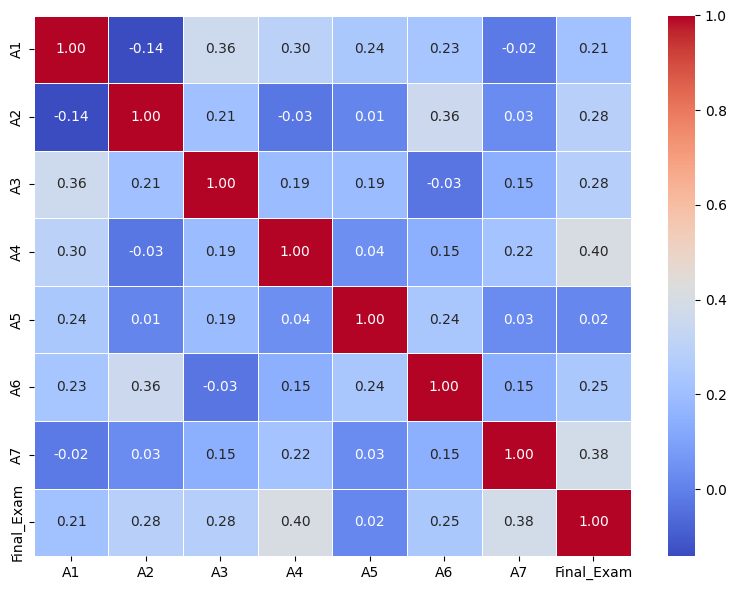

In [162]:
plt.figure(figsize=(8,6 ))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
# fmt=".2f" -> Two digits floating point
plt.tight_layout()
plt.show()

#### **Do any assignments seem strongly related to final exam performance?**
Based on the correlation matrixes:
- A4 has the strongest positive correlation with final exam score with 0.40
    - So as the score for A4 goes up, so does the score for the final exam.
    
- A5 seems to have the least correlation on the final exam score with a positive 0.02 only

### Assignment Choice Justification
**If you could only use two assignment grades to predict the final exam**, which ones would you choose — and why?


I decided to focus on the correlation between A1, A4, and the final exam. 
- This is because it most closely mimics the structure of a first exam (A1), midterm (A4), and then a final.

- Looking over the dataset as well, A1 and A4 have a large range of scores including 0 and negative scores

- A4 has been proven to have the strongest correlation with the final exam scores

**A4**: up to **5** bonus points


## Check for missing values

#### Which columns have them?
Based off the initial df.info(), all the columns except for the Final_Exam and user_id columns have values missing


In [163]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   A1          57 non-null     float64
 1   A2          61 non-null     float64
 2   A3          62 non-null     float64
 3   A4          77 non-null     float64
 4   A5          61 non-null     float64
 5   A6          67 non-null     float64
 6   A7          76 non-null     float64
 7   Final_Exam  86 non-null     float64
 8   user_id     86 non-null     str    
dtypes: float64(8), str(1)
memory usage: 6.2 KB


#### How many are missing?
As there are supposed to be 86 total entries, that means:
- **A1:** 29 missing
- **A2:** 25 missing
- **A3:** 24 missing
- **A4:** 9 missing
- **A5:** 25 missing
- **A6:** 19 missing
- **A7:** 10 missing

## Handle the missing values
  - Which one gives you the best results? Why do you think that is?
  - Exploration idea: search and see what are the ways of evaluating your results. How can you make sure that a strategy for handling the missing values works better than the other?


#### Data Copying / Cleaning
First, I will created a copy of the dataframe to focus on A1, A4, and Final_Exam

In [164]:
df_converted = df.drop(columns=['A2', 'A3', 'A5', 'A6', 'A7'])

numeric_cols = ['A1', 'A4', 'Final_Exam']
corr_matrix = df_converted[numeric_cols].corr()

print(corr_matrix.round(2))

              A1   A4  Final_Exam
A1          1.00  0.3        0.21
A4          0.30  1.0        0.40
Final_Exam  0.21  0.4        1.00


Then I will convert any negative scores to 0, that way when I do mean and median calculations it won't create outliers and give me a more accurate average.
- Negative scores will be treated equivalent to 0 in this case.

I used this Stack to help me clip the lowest score to 0:
https://stackoverflow.com/questions/68929284/how-to-replace-nan-and-negative-number-with-zero

In [165]:
df_converted[['A1', 'A4']] = df_converted[['A1', 'A4']].clip(lower=0) 

#Since I know entry 67 for A4 has a negative score, I'll double check that it worked with that entry
#If the entry for 67 in A4 is 0, I know it worked.
df_converted.head(68)

,A1,A4,Final_Exam,user_id
0,NaN,75.0,68.8,U001
1,100.0,92.5,50.3,U002
2,75.0,86.2,67.8,U003
3,25.0,0.0,0.0,U004
4,0.0,0.0,0.0,U005
...,...,...,...,...
63,NaN,81.0,42.8,U064
64,75.8,85.0,33.4,U065
65,95.8,NaN,35.6,U066
66,NaN,95.0,52.5,U067


Because A4 allows for bonus 5 marks, and we do not know what the max score a student can get is, I will leave the higher marks alone.

#### Try out different imputation strategies (mean, median, remove, etc.)

##### Remove
Drop rows that have missing values in columns A1 or A4

In [166]:
df_option1 = df_converted.dropna(subset=['A1', 'A4'])
print(f"Original dataset size: {len(df)}")
print(f"After removing missing values: {len(df_option1)}")
print(f"Rows with missing values removed: {len(df_converted) - len(df_option1)}")
df_option1.head(10)

Original dataset size: 86
After removing missing values: 52
Rows with missing values removed: 34


,A1,A4,Final_Exam,user_id
1,100.0,92.5,50.3,U002
2,75.0,86.2,67.8,U003
3,25.0,0.0,0.0,U004
4,0.0,0.0,0.0,U005
5,100.0,96.2,97.5,U006
6,95.8,175.8,64.4,U007
7,168.9,95.0,40.6,U008
8,83.3,90.0,51.9,U009
9,129.9,93.8,65.3,U010
10,75.0,96.2,55.6,U011


In [167]:
corr_matrix = df_option1[numeric_cols].corr()
print(corr_matrix.round(2))

              A1    A4  Final_Exam
A1          1.00  0.31        0.22
A4          0.31  1.00        0.41
Final_Exam  0.22  0.41        1.00


##### Mean
I used this medium article by Noor Fatima to help me with the code:
https://medium.com/@noorfatimaafzalbutt/mean-and-median-imputation-in-pandas-a-practical-guide-86efa3bf58cd

In [168]:
# Create a copy of the original dataset
df_mean_replaced = df_converted.copy()

# Calculate mean A1 scores
mean_A1 = df_converted['A1'].mean().round(2)
# Calculate mean A4 scores
mean_A4 = df_converted['A4'].mean().round(2)

# Fill missing values with the mean
df_mean_replaced['A1'] = df_mean_replaced['A1'].fillna(mean_A1)
df_mean_replaced['A4'] = df_mean_replaced['A4'].fillna(mean_A4)

print(f"Original dataset size: {len(df)}")
print(f"After replacing outliers with mean: {len(df_mean_replaced)}")
print(f"Mean A1 used for replacement: {mean_A1:.2f}")
print(f"Mean A4 used for replacement: {mean_A4:.2f}")
print(f"Rows with missing values removed: {len(df_converted) - len(df_mean_replaced)}")
print()

df_mean_replaced.head(10)



Original dataset size: 86
After replacing outliers with mean: 86
Mean A1 used for replacement: 83.75
Mean A4 used for replacement: 82.61
Rows with missing values removed: 0



,A1,A4,Final_Exam,user_id
0,83.75,75.0,68.8,U001
1,100.00,92.5,50.3,U002
2,75.00,86.2,67.8,U003
3,25.00,0.0,0.0,U004
4,0.00,0.0,0.0,U005
5,100.00,96.2,97.5,U006
6,95.80,175.8,64.4,U007
7,168.90,95.0,40.6,U008
8,83.30,90.0,51.9,U009
9,129.90,93.8,65.3,U010


In [169]:
corr_matrix = df_mean_replaced[numeric_cols].corr()
print(corr_matrix.round(2))

              A1    A4  Final_Exam
A1          1.00  0.28        0.18
A4          0.28  1.00        0.39
Final_Exam  0.18  0.39        1.00


##### Median


In [170]:
df_median_replaced = df_converted.copy()

# Calculate median A1 scores
median_A1 = df_converted['A1'].median().round(2)
# Calculate median A4 scores
median_A4 = df_converted['A4'].median().round(2)

# Fill missing values with the median
df_median_replaced['A1'] = df_median_replaced['A1'].fillna(median_A1)
df_median_replaced['A4'] = df_median_replaced['A4'].fillna(median_A4)

print(f"Median A1 used for replacement: {median_A1:.2f}")
print(f"Median A4 used for replacement: {median_A4:.2f}")

df_median_replaced.head(10)


Median A1 used for replacement: 87.50
Median A4 used for replacement: 87.50


,A1,A4,Final_Exam,user_id
0,87.5,75.0,68.8,U001
1,100.0,92.5,50.3,U002
2,75.0,86.2,67.8,U003
3,25.0,0.0,0.0,U004
4,0.0,0.0,0.0,U005
5,100.0,96.2,97.5,U006
6,95.8,175.8,64.4,U007
7,168.9,95.0,40.6,U008
8,83.3,90.0,51.9,U009
9,129.9,93.8,65.3,U010


In [171]:
corr_matrix = df_median_replaced[numeric_cols].corr()
print(corr_matrix.round(2))

              A1    A4  Final_Exam
A1          1.00  0.28        0.18
A4          0.28  1.00        0.40
Final_Exam  0.18  0.40        1.00


#### Which one gives you the best results? Why do you think that is?
In terms of accurate correlation, all the options closely resemble the original dataframe's matrix with maybe being one to three points off.

It's all positive correlation in the end.

Personally, I think removing the missing entries gives you the most accurate and best results. 

Students who have missing values for that assignment are removed from the column, and therefore you get a more accurate image of students who manage to do all of the assignments and what their final exam score might be.

## Check for outliers
  - Compare the results


#### Identify values that seem unrealistic or suspicious

For this, I will use the converted dataset that focused on the A1 and A4 columns. 
- I will also use the dataset that removed the rows with missing entries.

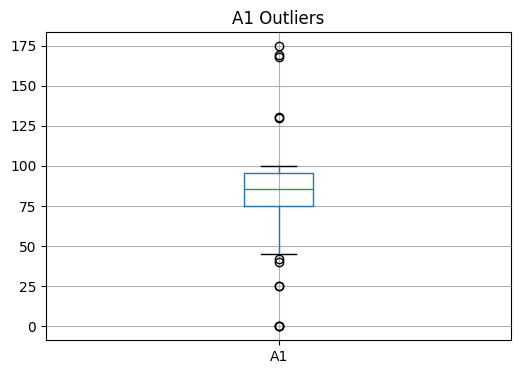

In [172]:
df_option1.boxplot(column='A1', figsize=(6,4))
plt.title("A1 Outliers")

plt.show()

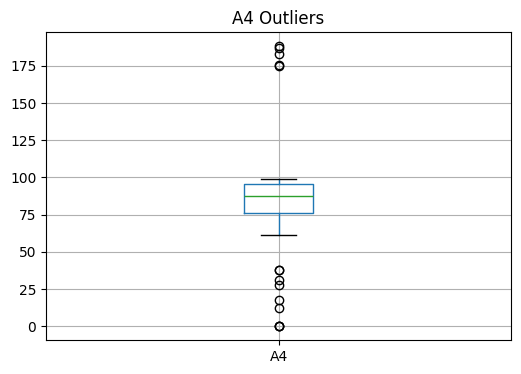

In [173]:
df_option1.boxplot(column='A4', figsize=(6,4))
plt.title("A4 Outliers")
plt.show()

In [174]:
def detect_outliers(df, column):
    mean = df[column].mean() # the mean = mean of that specific data column
    std = df[column].std() # standard deviation
    lower_bound = mean - 2 * std # mean -2 std
    higher_bound = mean + 2 * std # mean +2 std
    return df[(df[column] < lower_bound) | (df[column] > higher_bound)] 
#return dataframe with
# condition 1: either lower than lower bound OR
# condition 2: higher than higher bound

A1_outliers = detect_outliers(df_option1, 'A1')
A4_outliers = detect_outliers(df_option1, 'A4')

print('======== A1 outliers ========')
print(A1_outliers)
print()
print('======== A4 outliers ========')
print(A4_outliers)

======== A1 outliers ========
       A1    A4  Final_Exam user_id
4     0.0   0.0         0.0    U005
7   168.9  95.0        40.6    U008
15  168.1  87.5        46.6    U016
16  174.6  87.5        65.3    U017
44    0.0  98.8        82.5    U045
69    0.0  83.8        61.9    U070

======== A4 outliers ========
       A1     A4  Final_Exam user_id
6    95.8  175.8        64.4    U007
24  130.7  188.2        68.8    U025
30   83.3  183.1        49.1    U031
36   87.5  187.1        68.4    U037
82   87.5  174.8        64.1    U083


With this, we can create a list of outliers for each assignment
- Using this list we can modify the data directly

In [175]:
A1_outliers_list = ['U005', 'U008', 'U016', 'U017', 'U045', 'U070']
A4_outliers_list = ['U007', 'U025', 'U031', 'U037', 'U083']

#### Decide whether to keep, modify, or remove them — and explain your reasoning

##### Remove Outliers
I decided to remove these entries because they are so extreme. I think this will give us a better idea of the average when we do calculations on them. A more realistic expectation of what students are usually capable of.

In [182]:
# Combine all outlier IDS into a single list
all_outlier_ids = ['U005', 'U008', 'U016', 'U017', 'U045', 'U070', 'U007', 'U025', 'U031', 'U037', 'U083']

#remove outliers by excluding the users in the list
df_outliers_removed = df_option1[~df_option1['user_id'].isin(all_outlier_ids)].copy()

print(f"Original dataset size: {len(df_option1)}")
print(f"Isolated outliers dataset size: {len(all_outlier_ids)}")
print(f"Clean dataset size (after removing outliers): {len(df_outliers_removed)}")
print(f"Total rows removed: {len(df_option1) - len(df_outliers_removed)}")
print()
print("New Outliers for A1 & A4")
print(detect_outliers(df_outliers_removed, 'A1'))
print()
print(detect_outliers(df_outliers_removed, 'A4'))


Original dataset size: 52
Isolated outliers dataset size: 11
Clean dataset size (after removing outliers): 41
Total rows removed: 11

New Outliers for A1 & A4
       A1    A4  Final_Exam user_id
3    25.0   0.0         0.0    U004
9   129.9  93.8        65.3    U010
74   25.0  95.0        50.0    U075

      A1    A4  Final_Exam user_id
3   25.0   0.0         0.0    U004
18  83.3  12.5        54.7    U019
67  90.0   0.0        67.5    U068


#### Compare the results

In [186]:
print('Correlation Matrix of dataset, missing rows removed + outliers still intact')
corr_matrix = df_option1[numeric_cols].corr()
print(corr_matrix.round(2))

print()

print('Correlation Matrix of dataset, missing rows removed + outliers removed')
corr_matrix = df_outliers_removed[numeric_cols].corr()
print(corr_matrix.round(2))

Correlation Matrix of dataset, missing rows removed + outliers still intact
              A1    A4  Final_Exam
A1          1.00  0.31        0.22
A4          0.31  1.00        0.41
Final_Exam  0.22  0.41        1.00

Correlation Matrix of dataset, missing rows removed + outliers removed
              A1    A4  Final_Exam
A1          1.00  0.36        0.39
A4          0.36  1.00        0.39
Final_Exam  0.39  0.39        1.00


The correlation between the assignments and the final exam become uniform when the outliers are removed.

I think in this case, having outliers is necessary since it is such subjective result data. Having some unpredictable students actually allow for a more robust data analysis.